# VCO

## Target spec

source coupled VCO seem simple and easy to tune frequency than ring OSC.
because of tuning simplicity , this VCO just have one capacitor. current for charge/discharge also controlled by current mirror. important point is defining Vth , oscillation voltage is (Vdd-Vth) to (Vdd-3Vth).
frequency of OSC is defined:

Fosc = Id / ( 4 * C * Vth)

|  VCO Frequency   | 65-80MHz(FM RADIO 76-90MHz - IF:10.7MHz) |


## Calculate VCO parameter

nmos_vth:0.589748
mim_cap_capacitance:3.5e-11
fosc_max:80000000.0
fosc_min:65000000.0
fosc_range:15000000.0
fosc_upper_lim:81500000.0
fosc_lower_lim:63500000.0
id_diff_uppper_lower:5e-05
--------------------------
design result:
suitable_mim_cap_capacitance:1.18pf
suitable_id_upper:226.39uA
suitable_id_lower:176.39uA


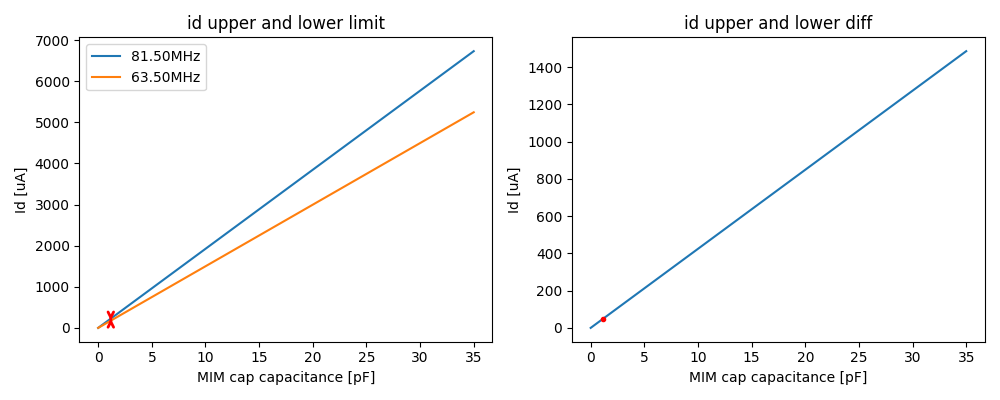

In [10]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate


# VCO spec and limitation
nmos_vth=0.589748
mim_cap_capacitance_max=35e-12
fosc_max=80e6
fosc_min=65e6
id_diff_uppper_lower=50e-6


fosc_range=fosc_max-fosc_min
# Add frequency margin +-10%
fosc_upper_lim=fosc_max+fosc_range*0.1
fosc_lower_lim=fosc_min-fosc_range*0.1

mim_cap_range = np.linspace(0,mim_cap_capacitance_max,100)
id_upper_lim_range=mim_cap_range*fosc_upper_lim*4*nmos_vth
id_lower_lim_range=mim_cap_range*fosc_lower_lim*4*nmos_vth
id_upper_lower_lim_diff_range=id_upper_lim_range-id_lower_lim_range
f_id_upper_lower_lim_diff_range_to_mim_cap_range = interpolate.interp1d(id_upper_lower_lim_diff_range, mim_cap_range)
suitable_mim_cap_capacitance=f_id_upper_lower_lim_diff_range_to_mim_cap_range(id_diff_uppper_lower)
f_mim_cap_range_to_id_upper_lim_range = interpolate.interp1d(mim_cap_range, id_upper_lim_range)
f_mim_cap_range_to_id_lower_lim_range = interpolate.interp1d(mim_cap_range, id_lower_lim_range)
suitable_id_upper=f_mim_cap_range_to_id_upper_lim_range(suitable_min_cap_capacitance)
suitable_id_lower=f_mim_cap_range_to_id_lower_lim_range(suitable_min_cap_capacitance)

# Print design parameter
print(f"nmos_vth:{nmos_vth}")
print(f"mim_cap_capacitance:{mim_cap_capacitance_max}")
print(f"fosc_max:{fosc_max}")
print(f"fosc_min:{fosc_min}")
print(f"fosc_range:{fosc_range}")
print(f"fosc_upper_lim:{fosc_upper_lim}")
print(f"fosc_lower_lim:{fosc_lower_lim}")
print(f"id_diff_uppper_lower:{id_diff_uppper_lower}")
print("--------------------------")
print("design result:")
print(f"suitable_mim_cap_capacitance:{suitable_mim_cap_capacitance/ 1e-12:.2f}pf")
print(f"suitable_id_upper:{suitable_id_upper/ 1e-6:.2f}uA")
print(f"suitable_id_lower:{suitable_id_lower/ 1e-6:.2f}uA")

# Plot result
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# 1st chart
axes[0].set_title('id upper and lower limit')
axes[0].set_xlabel("MIM cap capacitance [pF]")
axes[0].set_ylabel("Id [uA]")
axes[0].plot(mim_cap_range/1e-12, id_upper_lim_range/1e-6,label=f"{fosc_upper_lim / 1e6:.2f}MHz")
axes[0].plot(mim_cap_range/1e-12, id_lower_lim_range/1e-6,label=f"{fosc_lower_lim / 1e6:.2f}MHz")
axes[0].legend()
axes[0].annotate("", xy=(suitable_min_cap_capacitance/1e-12, suitable_id_upper/1e-6), xytext=(suitable_min_cap_capacitance/1e-12, suitable_id_lower/1e-6),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))

# 2nd chart
axes[1].set_title('id upper and lower diff')
axes[1].set_xlabel("MIM cap capacitance [pF]")
axes[1].set_ylabel("Id [uA]")
axes[1].plot(mim_cap_range/1e-12, id_upper_lower_lim_diff_range/1e-6)
axes[1].plot(suitable_min_cap_capacitance/1e-12,id_diff_uppper_lower/1e-6,marker='.',color="red")

plt.tight_layout()
plt.show()